# Разведочный анализ данных

In [312]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [313]:
df = pd.read_csv("data/interim/train.csv", index_col=0)

In [314]:
df

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,description,state,lat,long,posting_date
0,des moines,8000,2010.0,cadillac,srx,NaN,NaN,gas,172000.0,clean,automatic,NaN,NaN,NaN,Hey I have a 2010 Cadillac SRX Runs and drive...,ia,41.673000,-93.702800,2021-04-27T19:20:01-0500
1,tulsa,18325,2016.0,ford,explorer,good,6 cylinders,gas,115813.0,clean,automatic,4wd,SUV,green,"2016 Ford Explorer Limited 4WD - $18,325 Year...",ok,37.096900,-94.505100,2021-04-16T10:23:33-0500
2,monroe,17800,2014.0,chevrolet,silverado lt,NaN,NaN,gas,189000.0,clean,automatic,NaN,truck,white,The exterior is white and has tow package and ...,la,32.513553,-92.112690,2021-04-23T08:25:47-0500
3,maine,8500,2014.0,ford,focus,like new,4 cylinders,gas,80204.0,clean,automatic,fwd,hatchback,red,"Only $8,500! 38MPG ''Ruby Red'' 5-door All-Ne...",me,43.512501,-71.495697,2021-04-22T14:01:24-0400
4,flint,4900,2003.0,ram,van 1500,good,6 cylinders,gas,59000.0,clean,automatic,rwd,van,purple,"2003 Dodge Ram Van 1500, 59,000 miles, Side en...",mi,42.911700,-83.987700,2021-05-04T13:03:38-0400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189591,norfolk / hampton roads,33590,2018.0,ford,f150 super cab lariat,good,6 cylinders,other,38989.0,clean,other,4wd,pickup,NaN,Carvana is the safer way to buy a car During t...,va,36.670000,-76.300000,2021-04-10T13:31:43-0400
189592,fort collins / north CO,31900,2017.0,ram,1500 big horn,like new,8 cylinders,gas,75316.0,clean,automatic,4wd,truck,red,2017 Ram 1500 Crew Cab Big Horn HEMI 4WD!!!Bui...,co,40.601103,-105.076630,2021-04-20T14:29:23-0600
189593,ventura county,13500,2013.0,acura,ilx,excellent,4 cylinders,gas,86315.0,clean,automatic,fwd,sedan,white,Sharp and crisp this Acura is ready for a nigh...,ca,34.252965,-119.158779,2021-04-23T09:53:28-0700
189594,akron / canton,11733,2014.0,toyota,camry,excellent,4 cylinders,gas,93083.0,clean,automatic,fwd,sedan,grey,2014 Toyota Camry L - (Cosmic Gray Mica) STO...,oh,41.246430,-81.358530,2021-04-22T14:21:32-0400


In [315]:
df.shape

(189596, 19)

In [316]:
nan_df = (df.isnull().mean() * 100).reset_index()
nan_df.columns = ["feature", "percentage"]
nan_df.sort_values('percentage', ascending=False, inplace=True)
nan_df

,feature,percentage
6,cylinders,37.806705
5,condition,35.470685
11,drive,29.083947
13,paint_color,27.659339
12,type,22.938775
3,manufacturer,4.330260
9,title_status,1.412477
4,model,1.356569
17,long,0.645056
16,lat,0.645056


In [317]:
df["price"].describe().apply(lambda x: f"{x:.2f}")

count    189596.00
mean      17860.46
std       14232.38
min         500.00
25%        6988.00
50%       13995.00
75%       25888.00
max      100000.00
Name: price, dtype: str

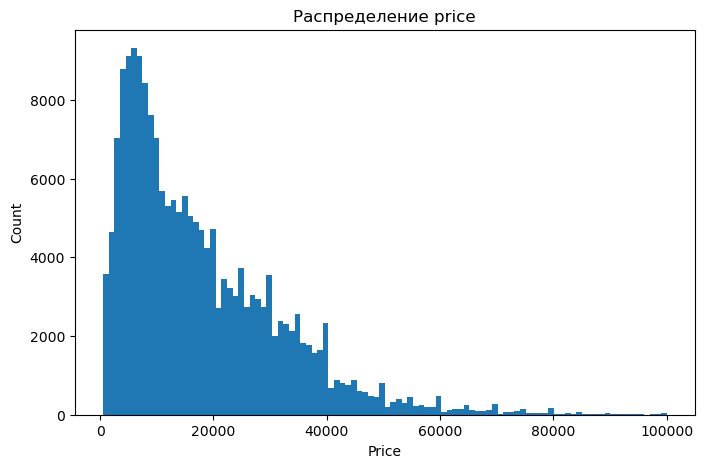

In [318]:
plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=100)
plt.title("Распределение price")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

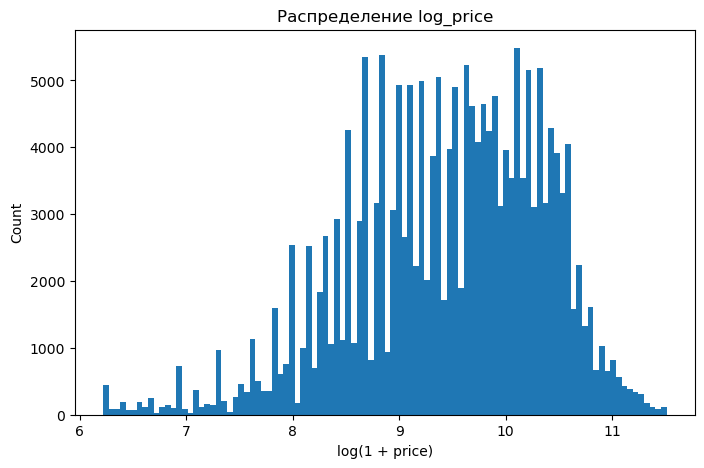

In [319]:
df["log_price"] = np.log1p(df["price"])

plt.figure(figsize=(8, 5))
plt.hist(df["log_price"], bins=100)
plt.title("Распределение log_price")
plt.xlabel("log(1 + price)")
plt.ylabel("Count")
plt.show()

In [320]:
df["year"].describe()

count    189065.000000
mean       2009.998990
std          10.520987
min        1900.000000
25%        2007.000000
50%        2013.000000
75%        2016.000000
max        2022.000000
Name: year, dtype: float64

In [321]:
df[df["year"] < 1960][["price", "year", "manufacturer", "model", "odometer"]].head(20)

,price,year,manufacturer,model,odometer
392,17500,1950.0,NaN,1950 plymouth,50000.0
589,13000,1954.0,mercury,"2 dr, sedan",77000.0
592,3500,1959.0,NaN,amc rambler,77000.0
654,22000,1947.0,NaN,Plymouth,12345.0
708,75000,1955.0,chevrolet,3100 truck,1600.0
719,12000,1937.0,pontiac,2 door touring sedan,34000.0
800,3000,1959.0,volkswagen,NaN,2354.0
872,28000,1957.0,chevrolet,NaN,2500.0
890,9995,1925.0,ford,NaN,15000.0
917,32500,1939.0,NaN,OLDSMOBILE SEDAN,19588.0


In [322]:
df[df["year"] < 1960].shape

(1482, 20)

In [323]:
df = df[((df["year"] >= 1980))]

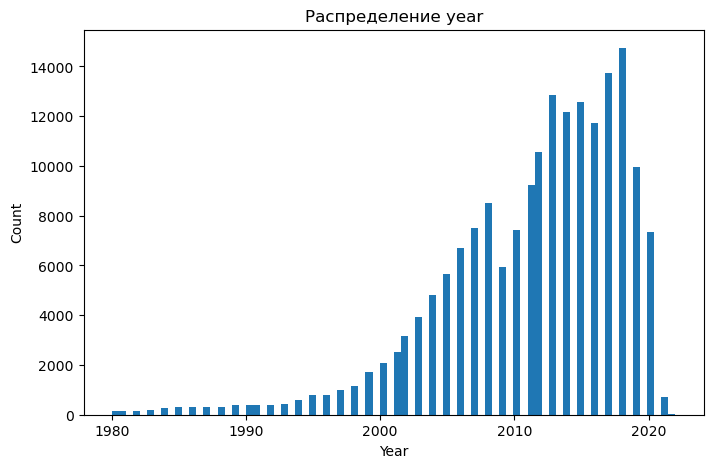

In [324]:
plt.figure(figsize=(8, 5))
plt.hist(df["year"].dropna(), bins=80)
plt.title("Распределение year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

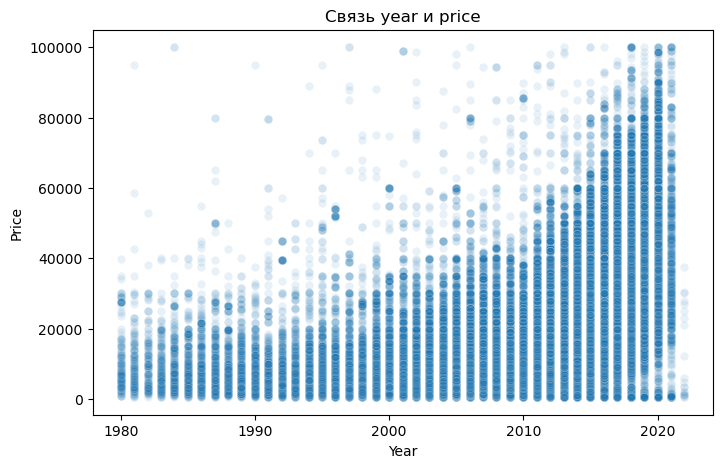

In [325]:
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="year",
    y="price",
    alpha=0.1
)

plt.title("Связь year и price")
plt.xlabel("Year")
plt.ylabel("Price")

plt.show()

In [326]:
df["year"] = df["year"].fillna(df["year"].mode()[0])

In [327]:
df["odometer"].describe().apply(lambda x: f"{x:.2f}")

count      183077.00
mean       103340.40
std        168222.09
min             0.00
25%         43000.00
50%         94498.00
75%        142000.00
max      10000000.00
Name: odometer, dtype: str

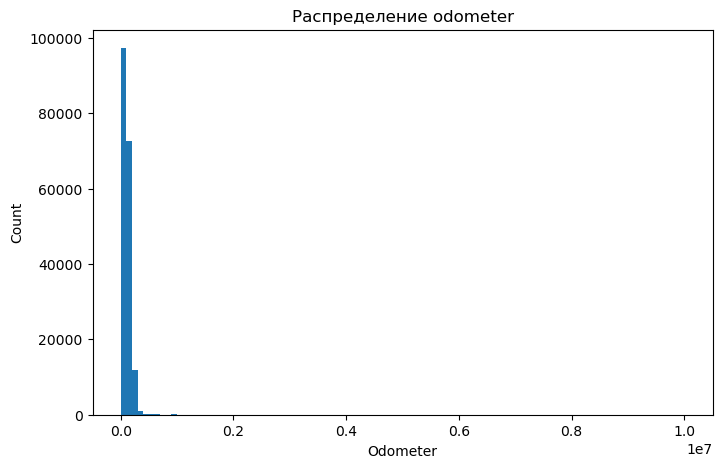

In [328]:
plt.figure(figsize=(8, 5))
plt.hist(df["odometer"].dropna(), bins=100)
plt.title("Распределение odometer")
plt.xlabel("Odometer")
plt.ylabel("Count")
plt.show()

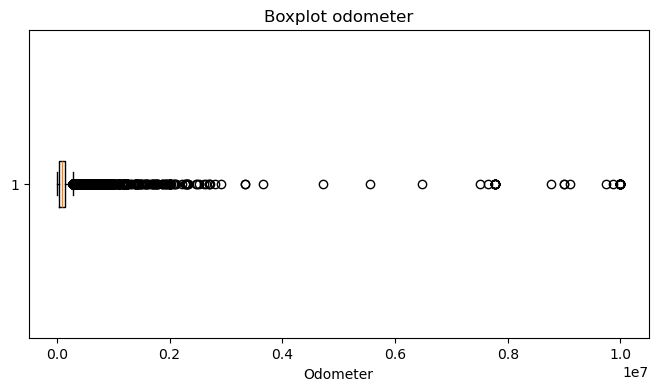

In [329]:
plt.figure(figsize=(8, 4))
plt.boxplot(df["odometer"].dropna(), vert=False)
plt.title("Boxplot odometer")
plt.xlabel("Odometer")
plt.show()

In [330]:
print("odometer = 0:", (df["odometer"] == 0).sum())
print("odometer > 500000:", (df["odometer"] > 500000).sum())

df[df["odometer"] > 500000][["price", "year", "manufacturer", "model", "odometer"]].head(20)

odometer = 0: 362
odometer > 500000: 525


,price,year,manufacturer,model,odometer
408,39000,1999.0,NaN,Mack CL713,684100.0
491,5900,2006.0,volvo,NaN,1001900.0
730,2500,2003.0,chevrolet,impala,1411877.0
1122,12995,2014.0,buick,encore,639900.0
1875,3500,2000.0,chevrolet,s10,999999.0
2732,40000,2012.0,NaN,freightliner columbia,600560.0
2987,4600,1990.0,ford,super duty dump,1000000.0
2996,38000,2002.0,NaN,freightliner columbia,670000.0
3376,3795,2006.0,subaru,forester,999999.0
3572,11900,2003.0,ford,f250 super duty powerstroke,999999.0


In [331]:
df = df[
    ((df["odometer"] > 0) & (df["odometer"] <= 500000))
].copy()

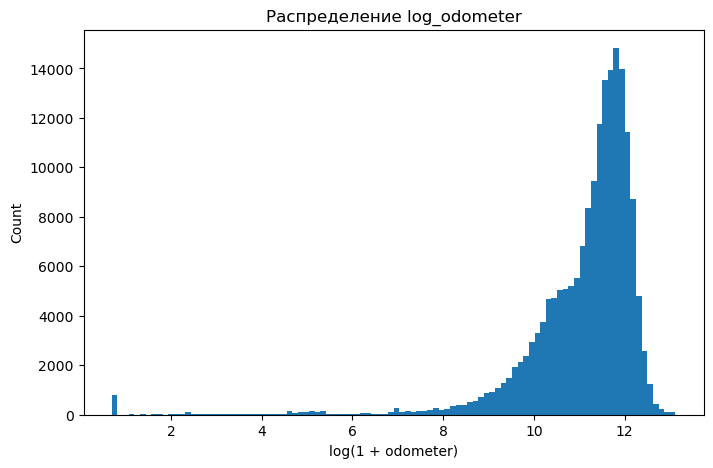

In [332]:
df["log_odometer"] = np.log1p(df["odometer"])

plt.figure(figsize=(8, 5))
plt.hist(df["log_odometer"].dropna(), bins=100)
plt.title("Распределение log_odometer")
plt.xlabel("log(1 + odometer)")
plt.ylabel("Count")
plt.show()

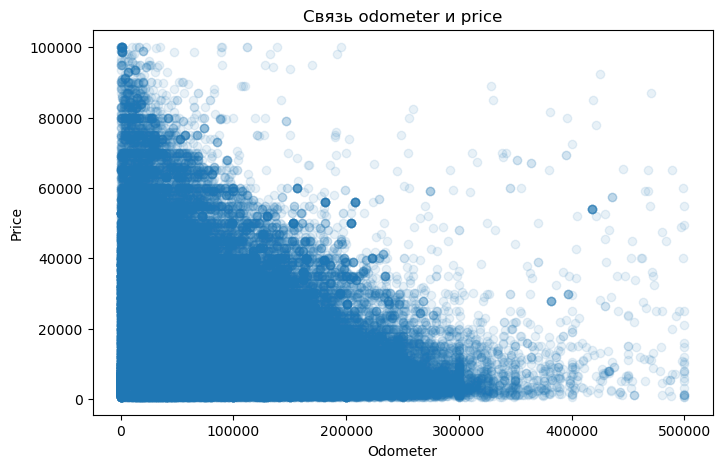

In [333]:
plt.figure(figsize=(8, 5))
plt.scatter(df["odometer"], df["price"], alpha=0.1)
plt.title("Связь odometer и price")
plt.xlabel("Odometer")
plt.ylabel("Price")
plt.show()

In [334]:
df["odometer"] = df["odometer"].fillna(df["odometer"].mean())

In [335]:
df["posting_date"] = pd.to_datetime(
    df["posting_date"],
    errors="coerce",
    utc=True
)

df["posting_year"] = df["posting_date"].dt.year
df["posting_month"] = df["posting_date"].dt.month

df = df.drop(columns=["posting_date"])

In [336]:
df["posting_year"].nunique()

1

In [337]:
df.drop(columns=["posting_year"], inplace=True)

In [338]:
df["posting_month"].nunique()

2

In [339]:
df.drop(columns=["posting_month"], inplace=True)

In [340]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

categorical_cols

C:\Users\VLAD\AppData\Local\Temp\ipykernel_10540\2376633327.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


['region',
 'manufacturer',
 'model',
 'condition',
 'cylinders',
 'fuel',
 'title_status',
 'transmission',
 'drive',
 'type',
 'paint_color',
 'description',
 'state']

In [341]:
cardinality_table = pd.DataFrame({
    "column": categorical_cols,
    "unique_count": [df[col].nunique(dropna=True) for col in categorical_cols],
    "missing_percent": [df[col].isna().mean() * 100 for col in categorical_cols]
})

cardinality_table = cardinality_table.sort_values("unique_count", ascending=False)

display(cardinality_table)

,column,unique_count,missing_percent
11,description,174065,0.000549
2,model,20444,1.123552
0,region,404,0.000000
12,state,51,0.000000
1,manufacturer,42,3.456831
9,type,13,22.334376
10,paint_color,12,27.329711
4,cylinders,8,37.974093
3,condition,6,35.433888
6,title_status,6,1.340908


In [342]:
df["model"].value_counts().head(20)

model
f-150             3155
silverado 1500    2036
1500              1662
camry             1490
accord            1430
silverado         1413
civic             1343
altima            1211
wrangler          1205
escape            1190
tacoma            1133
explorer          1058
grand cherokee    1051
2500              1000
corolla            981
mustang            914
cr-v               875
focus              828
equinox            823
fusion             789
Name: count, dtype: int64

In [343]:
model_counts = df["model"].value_counts(dropna=False)

n_unique = df["model"].nunique(dropna=False)

result = {
    "всего уникальных": n_unique,
    "встречаются 1 раз": (model_counts == 1).sum(),
    "встречаются меньше 5 раз": (model_counts < 5).sum(),
    "встречаются меньше 10 раз": (model_counts < 10).sum(),
    "встречаются меньше 20 раз": (model_counts < 20).sum(),
    "встречаются меньше 50 раз": (model_counts < 50).sum(),
}

result

{'всего уникальных': 20445,
 'встречаются 1 раз': np.int64(11946),
 'встречаются меньше 5 раз': np.int64(16281),
 'встречаются меньше 10 раз': np.int64(17979),
 'встречаются меньше 20 раз': np.int64(19067),
 'встречаются меньше 50 раз': np.int64(19896)}

In [344]:
model_counts = df["model"].value_counts(dropna=True)
popular_models = model_counts[model_counts >= 20].index

df["model"] = df["model"].fillna("unknown")

df["model"] = df["model"].where(
    df["model"].isin(popular_models) | (df["model"] == "unknown"),
    "other"
)

In [345]:
df["model"].nunique(dropna=False)

1379

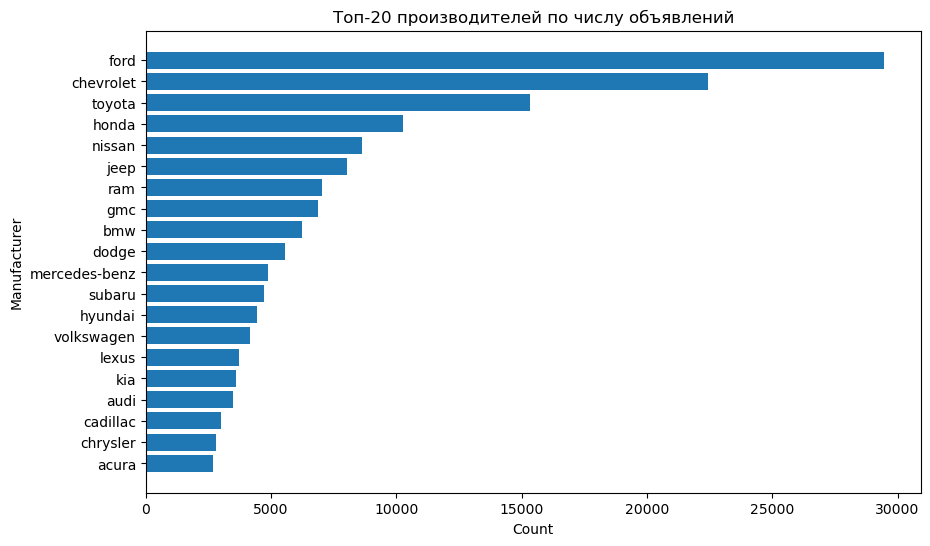

In [346]:
top_manufacturers = df["manufacturer"].value_counts().head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_manufacturers.index, top_manufacturers.values)
plt.title("Топ-20 производителей по числу объявлений")
plt.xlabel("Count")
plt.ylabel("Manufacturer")
plt.gca().invert_yaxis()
plt.show()

<Figure size 1200x600 with 0 Axes>

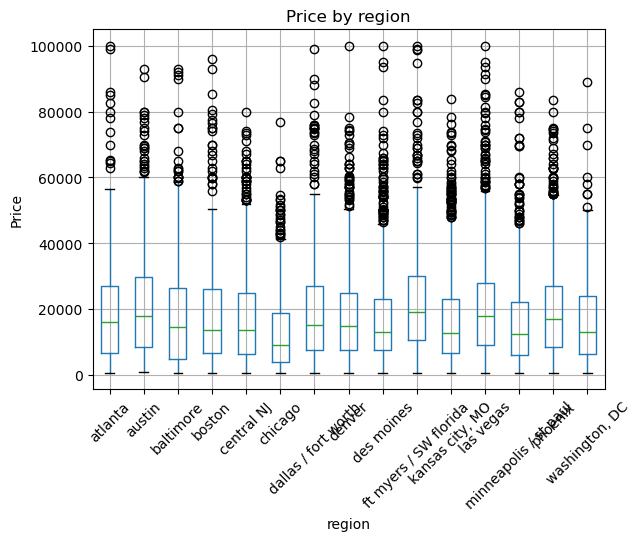

<Figure size 1200x600 with 0 Axes>

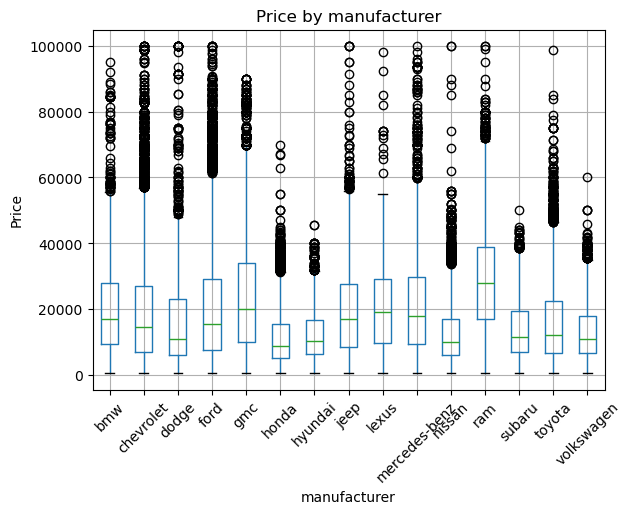

<Figure size 1200x600 with 0 Axes>

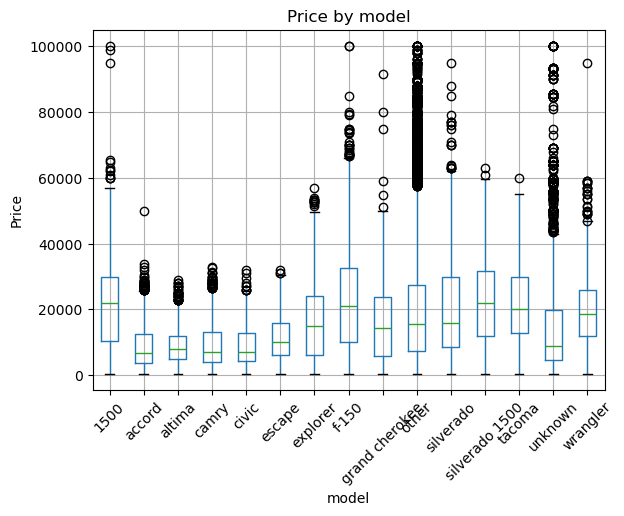

<Figure size 1200x600 with 0 Axes>

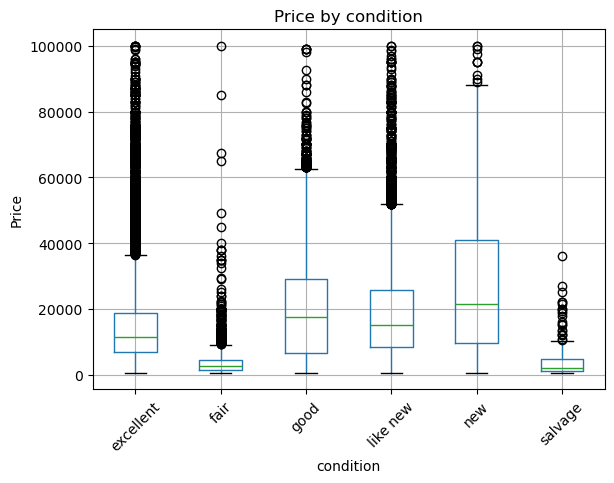

<Figure size 1200x600 with 0 Axes>

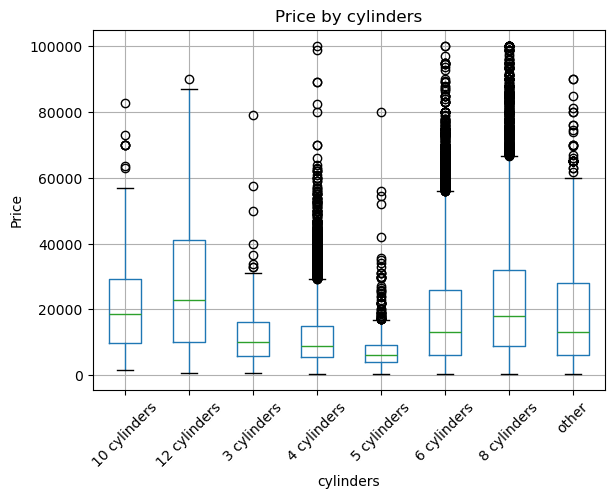

<Figure size 1200x600 with 0 Axes>

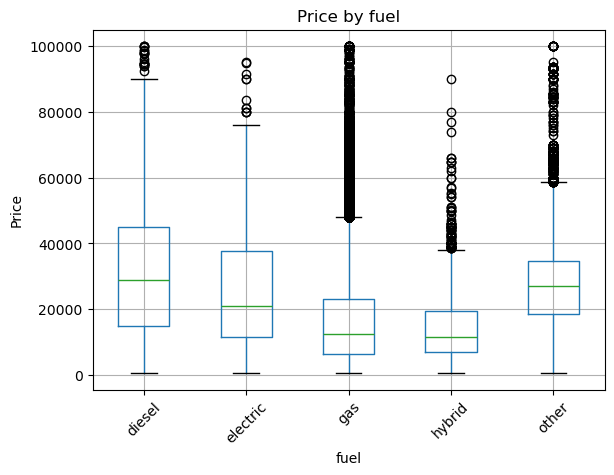

<Figure size 1200x600 with 0 Axes>

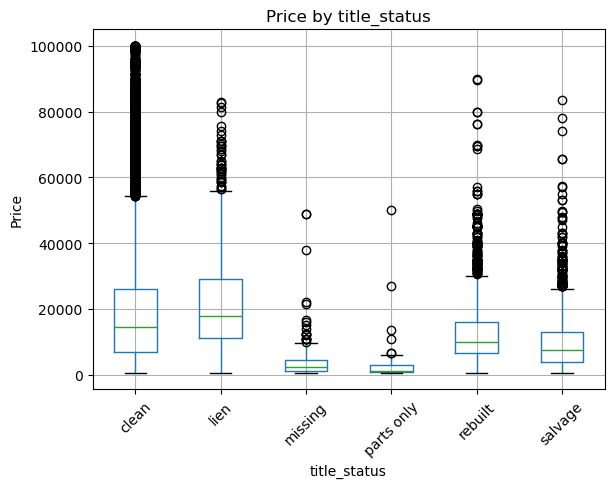

<Figure size 1200x600 with 0 Axes>

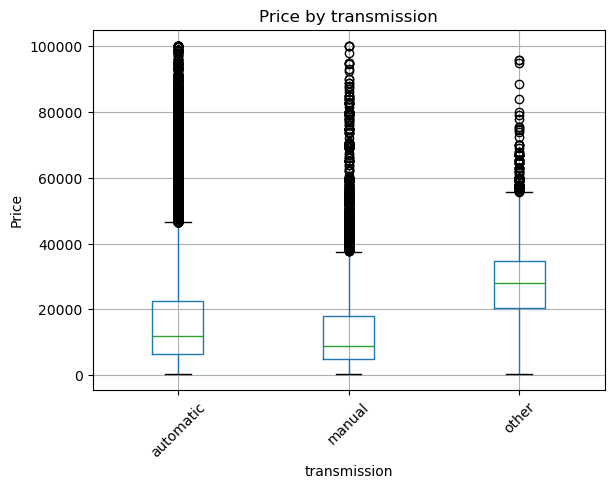

<Figure size 1200x600 with 0 Axes>

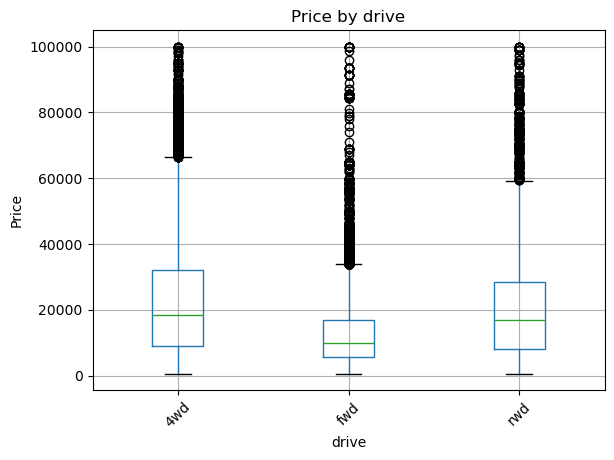

<Figure size 1200x600 with 0 Axes>

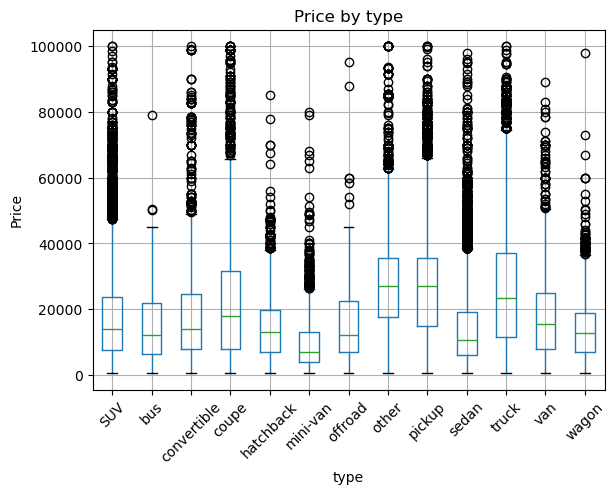

<Figure size 1200x600 with 0 Axes>

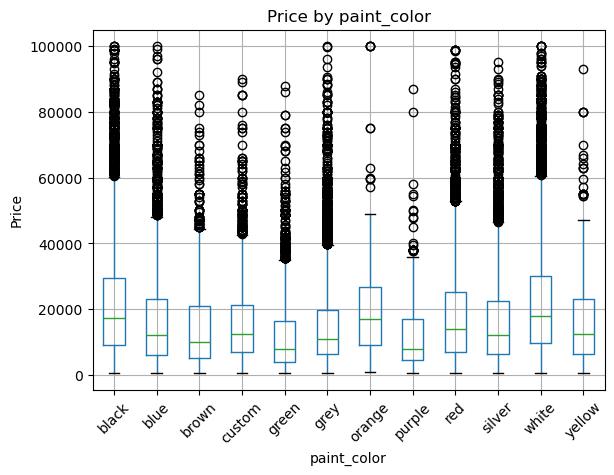

In [347]:
import matplotlib.pyplot as plt

categorical_features = [
    "region",
    "manufacturer",
    "model",
    "condition",
    "cylinders",
    "fuel",
    "title_status",
    "transmission",
    "drive",
    "type",
    "paint_color"
]

top_n = 15

for col in categorical_features:
    if col not in df.columns:
        print(f"Колонка {col} отсутствует в датасете")
        continue
    
    top_categories = df[col].value_counts().head(top_n).index
    
    plot_data = df[df[col].isin(top_categories)]
    
    plt.figure(figsize=(12, 6))
    plot_data.boxplot(column="price", by=col, rot=45)
    
    plt.title(f"Price by {col}")
    plt.suptitle("")
    plt.xlabel(col)
    plt.ylabel("Price")
    plt.show()

In [348]:
region_state_check = (
    df.groupby("region")["state"]
    .nunique()
    .sort_values(ascending=False)
)

display(region_state_check.head(20))

region
jackson                    3
jacksonville               2
lewiston / clarkston       2
fayetteville               2
charleston                 2
duluth / superior          2
columbus                   2
huntington-ashland         2
monroe                     2
omaha / council bluffs     2
pullman / moscow           2
reno / tahoe               2
richmond                   2
rochester                  2
albany                     2
spokane / coeur d'alene    2
springfield                2
athens                     2
waco                       1
washington, DC             1
Name: state, dtype: int64

In [349]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

geo_df = df.dropna(subset=["lat", "long", "state"]).copy()

X_geo = geo_df[["lat", "long"]]
y_state = geo_df["state"]

clf = DecisionTreeClassifier(
    max_depth=10,
)

scores = cross_val_score(
    clf,
    X_geo,
    y_state,
    cv=5,
    scoring="accuracy"
)

print("Accuracy predicting state from lat/long:", scores.mean())

Accuracy predicting state from lat/long: 0.8616315367827841


In [350]:
df["lat_long_missing"] = (
    df["lat"].isna() | df["long"].isna()
).astype(int)

for col in ["lat", "long"]:
    df[col] = df[col].fillna(
        df.groupby("state")[col].transform("median")
    )

    df[col] = df[col].fillna(df[col].median())

Штат сильно коррелирует с координатами, поэтому чтобы снизить количество one hot колонок стоит попробовать удалить этот признак

In [351]:
df.drop(columns=["state"], inplace=True)

In [352]:
geo_df = df.dropna(subset=["lat", "long", "region"]).copy()

X_geo = geo_df[["lat", "long"]]
y_state = geo_df["region"]

clf = DecisionTreeClassifier(
    max_depth=10,
)

scores = cross_val_score(
    clf,
    X_geo,
    y_state,
    cv=5,
    scoring="accuracy"
)

print("Accuracy predicting region from lat/long:", scores.mean())

c:\Users\VLAD\anaconda3\envs\HW2\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Accuracy predicting region from lat/long: 0.287688676656238


Признак region не дает сильной корреляции с координатами

In [353]:
from sklearn.cluster import KMeans

region_price = (
    df
    .assign(region=df["region"].fillna("unknown"))
    .groupby("region")["price"]
    .median()
    .reset_index()
)

kmeans = KMeans(
    n_clusters=10,
    n_init=10
)

region_price["region_cluster"] = kmeans.fit_predict(
    region_price[["price"]]
)

cluster_order = (
    region_price
    .groupby("region_cluster")["price"]
    .median()
    .sort_values()
    .index
)

cluster_map = {
    old_cluster: new_cluster
    for new_cluster, old_cluster in enumerate(cluster_order)
}

region_price["region_cluster"] = (
    region_price["region_cluster"]
    .map(cluster_map)
)

region_to_cluster = dict(
    zip(region_price["region"], region_price["region_cluster"])
)

df["region"] = df["region"].fillna("unknown")

df["region_price_cluster"] = (
    df["region"]
    .map(region_to_cluster)
    .astype("category")
)

df = df.drop(columns=["region"])

c:\Users\VLAD\anaconda3\envs\HW2\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [354]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

paint_color_price = (
    df
    .assign(paint_color=df["paint_color"].fillna("unknown"))
    .groupby("paint_color")["price"]
    .median()
    .reset_index()
)

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

paint_color_price["paint_color_cluster"] = kmeans.fit_predict(
    paint_color_price[["price"]]
)

cluster_order = (
    paint_color_price
    .groupby("paint_color_cluster")["price"]
    .median()
    .sort_values()
    .index
)

cluster_map = {
    old_cluster: new_cluster
    for new_cluster, old_cluster in enumerate(cluster_order)
}

paint_color_price["paint_color_cluster"] = (
    paint_color_price["paint_color_cluster"]
    .map(cluster_map)
)

paint_color_to_cluster = dict(
    zip(paint_color_price["paint_color"], paint_color_price["paint_color_cluster"])
)

df["paint_color"] = df["paint_color"].fillna("unknown")

df["paint_color_price_cluster"] = (
    df["paint_color"]
    .map(paint_color_to_cluster)
    .astype("category")
)

df = df.drop(columns=["paint_color"])

c:\Users\VLAD\anaconda3\envs\HW2\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [355]:
cols_to_fill = [
    "type",
    "drive",
    "transmission",
    "fuel",
    "condition",
    "manufacturer",
    "title_status"
]

for col in cols_to_fill:
    if col in df.columns:
        df[col] = df[col].fillna("unknown")

In [356]:
df["cylinders"].unique()

<StringArray>
[           nan,  '6 cylinders',  '4 cylinders',        'other',
  '8 cylinders', '10 cylinders',  '5 cylinders',  '3 cylinders',
 '12 cylinders']
Length: 9, dtype: str

In [357]:
import numpy as np

cylinders_map = {
    "3 cylinders": 3,
    "4 cylinders": 4,
    "5 cylinders": 5,
    "6 cylinders": 6,
    "8 cylinders": 8,
    "10 cylinders": 10,
    "12 cylinders": 12,
    "other": 0
}

df["cylinders_other"] = (df["cylinders"] == "other").astype(int)

df["cylinders"] = (
    df["cylinders"]
    .map(cylinders_map)
    .fillna(0)
    .astype(int)
)

In [358]:
df["description"] = df["description"].fillna("")

In [359]:
df.drop(columns=["price"], inplace=True)

In [360]:
nan_df = (df.isnull().mean() * 100).reset_index()
nan_df.columns = ["feature", "percentage"]
nan_df.sort_values('percentage', ascending=False, inplace=True)
nan_df

,feature,percentage
0,year,0.0
1,manufacturer,0.0
2,model,0.0
3,condition,0.0
4,cylinders,0.0
5,fuel,0.0
6,odometer,0.0
7,title_status,0.0
8,transmission,0.0
9,drive,0.0


In [361]:
df

,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,description,lat,long,log_price,log_odometer,lat_long_missing,region_price_cluster,paint_color_price_cluster,cylinders_other
0,2010.0,cadillac,srx,unknown,0,gas,172000.0,clean,automatic,unknown,unknown,Hey I have a 2010 Cadillac SRX Runs and drive...,41.673000,-93.702800,8.987322,12.055256,0,2,2,0
1,2016.0,ford,explorer,good,6,gas,115813.0,clean,automatic,4wd,SUV,"2016 Ford Explorer Limited 4WD - $18,325 Year...",37.096900,-94.505100,9.816076,11.659741,0,3,0,0
2,2014.0,chevrolet,other,unknown,0,gas,189000.0,clean,automatic,unknown,truck,The exterior is white and has tow package and ...,32.513553,-92.112690,9.787010,12.149508,0,2,4,0
3,2014.0,ford,focus,like new,4,gas,80204.0,clean,automatic,fwd,hatchback,"Only $8,500! 38MPG ''Ruby Red'' 5-door All-Ne...",43.512501,-71.495697,9.047939,11.292341,0,2,3,0
4,2003.0,ram,other,good,6,gas,59000.0,clean,automatic,rwd,van,"2003 Dodge Ram Van 1500, 59,000 miles, Side en...",42.911700,-83.987700,8.497195,10.985310,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189591,2018.0,ford,f150 super cab lariat,good,6,other,38989.0,clean,other,4wd,pickup,Carvana is the safer way to buy a car During t...,36.670000,-76.300000,10.422013,10.571060,0,1,2,0
189592,2017.0,ram,1500 big horn,like new,8,gas,75316.0,clean,automatic,4wd,truck,2017 Ram 1500 Crew Cab Big Horn HEMI 4WD!!!Bui...,40.601103,-105.076630,10.370393,11.229461,0,3,3,0
189593,2013.0,acura,ilx,excellent,4,gas,86315.0,clean,automatic,fwd,sedan,Sharp and crisp this Acura is ready for a nigh...,34.252965,-119.158779,9.510519,11.365770,0,0,4,0
189594,2014.0,toyota,camry,excellent,4,gas,93083.0,clean,automatic,fwd,sedan,2014 Toyota Camry L - (Cosmic Gray Mica) STO...,41.246430,-81.358530,9.370246,11.441258,0,1,1,0


In [362]:
df.columns

Index(['year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel',
       'odometer', 'title_status', 'transmission', 'drive', 'type',
       'description', 'lat', 'long', 'log_price', 'log_odometer',
       'lat_long_missing', 'region_price_cluster', 'paint_color_price_cluster',
       'cylinders_other'],
      dtype='str')

In [363]:
df = pd.read_csv("data/interim/train.csv", index_col=0)

In [364]:
df = df[((df["year"] >= 1980))]
df = df[
    ((df["odometer"] > 0) & (df["odometer"] <= 500000))
].copy()

In [365]:
df.to_csv("data/interim/train_filtered.csv")